In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. Đảm bảo thư mục tồn tại
os.makedirs('../data/raw', exist_ok=True)
file_path = '../data/raw/parking_data_raw.csv'

# 2. KIỂM TRA: Nếu file chưa có hoặc bị trống (0 byte), hệ thống sẽ tự động sinh dữ liệu tại chỗ!
if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
    print("⚠️ File dữ liệu trống! Đang tự động sinh 15000 dòng dữ liệu...")
    np.random.seed(42)
    student_ids = [f"SV{str(i).zfill(4)}" for i in range(1, 2001)]
    behaviors = ['Early_Return', 'Full_Day', 'Overnight', 'Long_Term']
    behavior_probs = [0.35, 0.50, 0.10, 0.05] 
    start_date = datetime(2023, 9, 1)
    end_date = datetime(2023, 12, 31)
    
    data = []
    for _ in range(15000):
        student = np.random.choice(student_ids)
        behavior = np.random.choice(behaviors, p=behavior_probs)
        random_days = np.random.randint(0, (end_date - start_date).days)
        current_date = start_date + timedelta(days=random_days)
        
        is_morning = np.random.choice([True, False], p=[0.65, 0.35])
        entry_hour_float = np.random.normal(loc=7.0 if is_morning else 12.75, scale=0.5)
        entry_hour_float = np.clip(entry_hour_float, 5.5, 18.0)
        entry_time = current_date + timedelta(hours=int(entry_hour_float), minutes=int((entry_hour_float % 1) * 60))
        
        if behavior == 'Early_Return': duration = np.random.uniform(1.0, 3.5)
        elif behavior == 'Full_Day': duration = np.random.uniform(4.0, 9.0)
        elif behavior == 'Overnight': duration = np.random.uniform(12.0, 24.0)
        else: duration = np.random.uniform(24.0, 72.0)
            
        data.append({
            'student_id': student, 
            'vehicle_type': np.random.choice(['Motorbike', 'Car'], p=[0.98, 0.02]),
            'entry_time': entry_time.strftime('%Y-%m-%d %H:%M:%S'),
            'exit_time': (entry_time + timedelta(hours=duration)).strftime('%Y-%m-%d %H:%M:%S'),
            'day_of_week': entry_time.strftime('%A'),
            'duration_minutes': int(duration * 60),
            'usual_zone': np.random.choice(['Zone_A', 'Zone_B', 'Zone_C', 'Zone_D'], p=[0.4, 0.3, 0.2, 0.1]), 
            'is_exam_week': 1 if current_date.month == 12 and current_date.day > 10 else 0,
            'parking_behavior': behavior
        })
        
    df_temp = pd.DataFrame(data)
    df_temp.to_csv(file_path, index=False)
    print("✅ Đã sinh xong và lưu vào file!")

# 3. Đọc dữ liệu (Lúc này chắc chắn 100% file đã có dữ liệu)
df = pd.read_csv(file_path)
df['entry_time'] = pd.to_datetime(df['entry_time'])
df['exit_time'] = pd.to_datetime(df['exit_time'])
df['entry_hour'] = df['entry_time'].dt.hour + df['entry_time'].dt.minute / 60

print(f"Kích thước dataset: {df.shape}")
df.head()

Kích thước dataset: (15000, 10)


,student_id,vehicle_type,entry_time,exit_time,day_of_week,duration_minutes,usual_zone,is_exam_week,parking_behavior,entry_hour
0,SV1127,Motorbike,2023-09-15 12:11:00,2023-09-15 16:57:47,Friday,286,Zone_C,0,Full_Day,12.183333
1,SV1124,Motorbike,2023-09-03 07:09:00,2023-09-03 10:34:29,Sunday,205,Zone_A,0,Early_Return,7.150000
2,SV1216,Motorbike,2023-10-03 05:41:00,2023-10-04 19:39:44,Tuesday,2278,Zone_A,0,Long_Term,5.683333
3,SV1500,Motorbike,2023-09-15 07:28:00,2023-09-17 21:09:18,Friday,3701,Zone_B,0,Long_Term,7.466667
4,SV0832,Motorbike,2023-12-10 06:41:00,2023-12-10 11:10:18,Sunday,269,Zone_B,0,Full_Day,6.683333


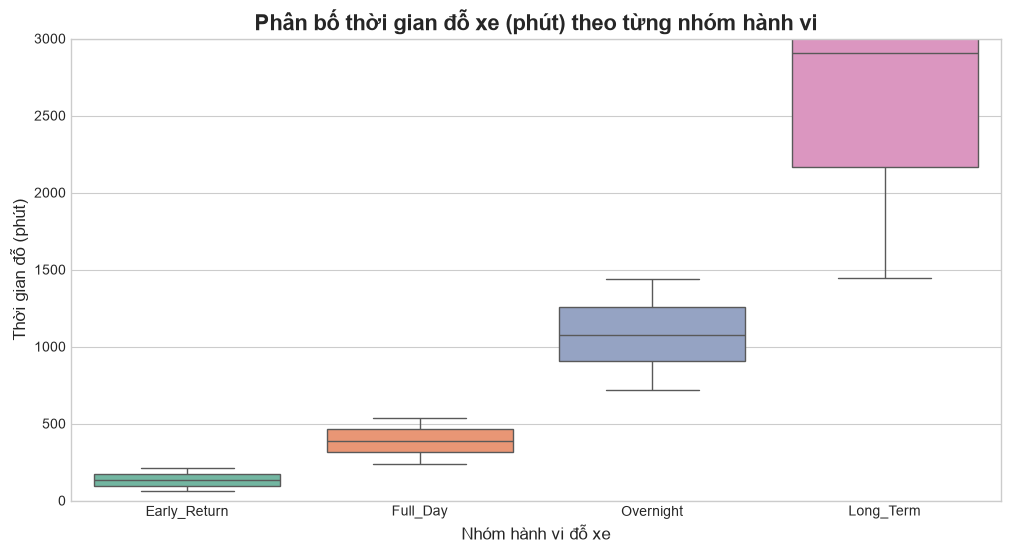

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='parking_behavior', y='duration_minutes', 
            order=['Early_Return', 'Full_Day', 'Overnight', 'Long_Term'],
            palette='Set2')

plt.title('Phân bố thời gian đỗ xe (phút) theo từng nhóm hành vi', fontsize=16, fontweight='bold')
plt.xlabel('Nhóm hành vi đỗ xe', fontsize=12)
plt.ylabel('Thời gian đỗ (phút)', fontsize=12)

# Giới hạn trục y để dễ nhìn các nhóm chính, cắt bớt đuôi của Long_Term quá dài
plt.ylim(0, 3000) 

plt.savefig('../outputs/figures/parking_duration.png', dpi=300, bbox_inches='tight')
plt.show()

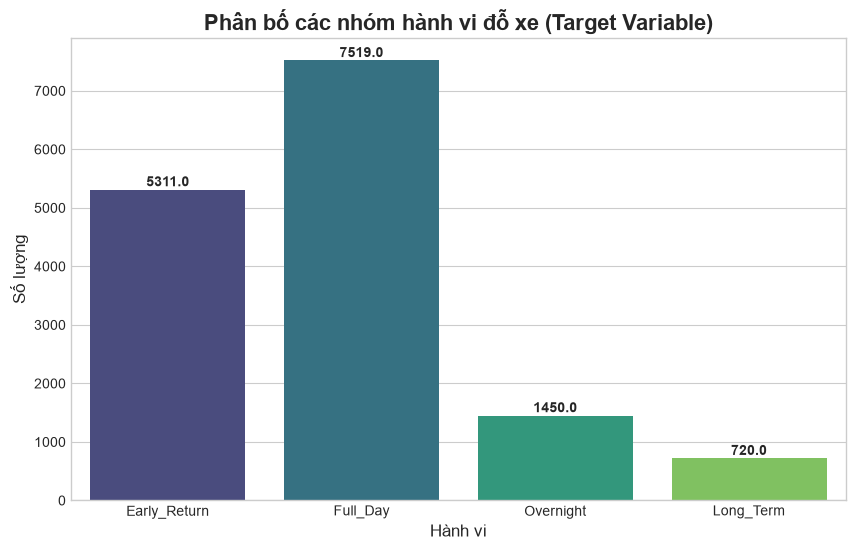

In [5]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='parking_behavior', 
                   order=['Early_Return', 'Full_Day', 'Overnight', 'Long_Term'],
                   palette='viridis')

plt.title('Phân bố các nhóm hành vi đỗ xe (Target Variable)', fontsize=16, fontweight='bold')
plt.xlabel('Hành vi', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)

# Thêm số liệu trên từng cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.savefig('../outputs/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

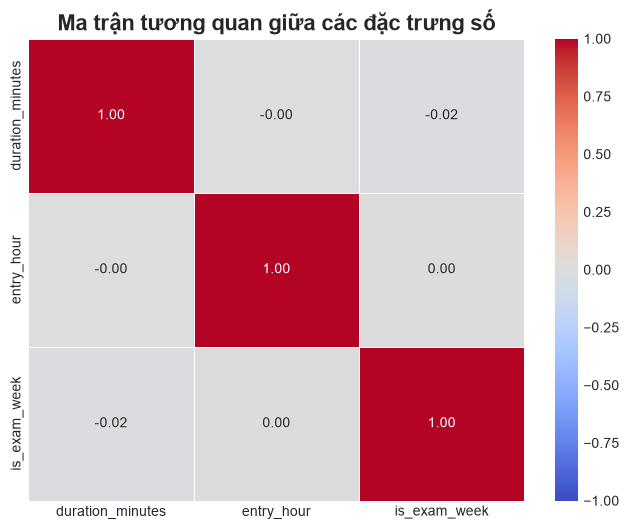

In [6]:
# Chọn các cột dạng số để tính toán tương quan
numeric_cols = ['duration_minutes', 'entry_hour', 'is_exam_week']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Ma trận tương quan giữa các đặc trưng số', fontsize=16, fontweight='bold')
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

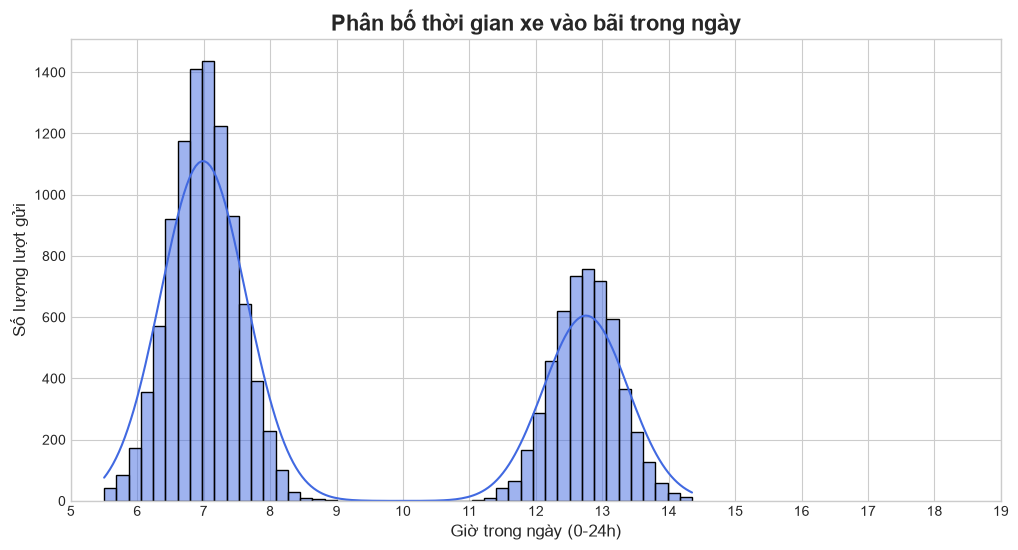

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(df['entry_hour'], bins=48, kde=True, color='royalblue')

plt.title('Phân bố thời gian xe vào bãi trong ngày', fontsize=16, fontweight='bold')
plt.xlabel('Giờ trong ngày (0-24h)', fontsize=12)
plt.ylabel('Số lượng lượt gửi', fontsize=12)
plt.xticks(np.arange(5, 20, 1))
plt.xlim(5, 19)

# Lưu hình ảnh vào thư mục outputs
plt.savefig('../outputs/figures/entry_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()